# 07: build the clustering from scratch, then find the pregnancy changes

Until now somebody handed you the lipizones. Pixels arrived pre-coloured by territory, and you
trusted the colours. Today we earn them. We build a clustering algorithm with our own hands, one
recursive split at a time, and we discover the single rule that turns a clustering into *biology*: a
split is only allowed to exist if the two halves it creates differ in real, measurable lipids.

That rule is a statistical test, the Mann-Whitney rank-sum test with a Benjamini-Hochberg correction.
We build that test from the ground up too, because it is the same machine we then point at the real
question of this course: what does pregnancy do to the lipids of the brain? The two halves of the
notebook are one idea used twice. First we split a healthy brain into territories and demand that each
split be backed by differential lipids. Then we hold a territory fixed and ask whether control and
pregnant pixels inside it differ. Same test, two jobs.

Here is the road:

> a divisive splitter from scratch (re-embed, cut in two, gate on differential lipids), then the
> Mann-Whitney plus Benjamini-Hochberg test unrolled, then control versus pregnant per lipizone, the
> volcano, marker lipids and the sorted heatmaps that read out what each territory is made of, and
> finally composite scores (membrane remodeling, myelination) painted back onto the tissue.

Every number below comes from code that runs on the two real sections you have been carrying through
the course, one control brain and one pregnant brain at the same coronal plane. Nothing is invented,
and these are *your* lipizones, the ones the previous notebooks built, not the paper's. They will not
match the atlas exactly, and that honesty is the whole point: you will watch the broad biology survive
anyway.

## the callouts

The four markers from the earlier notebooks carry through here too:

- 🔬 **TASK** something you do (write or run code).
- 💡 **HINT** a nudge when you are stuck.
- ❓ **QUESTION** pause and think, no code required.
- **check:** what you should see if it worked. If your screen disagrees, fix it before moving on.

One working habit for this notebook in particular. The first half we build by hand, so you see every
gear. The second half leans on the course helpers, the tested versions of those same gears. Every time
you call one, do not treat it as a black box: 💡 **HINT** open
`src/cajal_lipidomics/<module>.py` and read the function before you run it. The helpers are short and
readable on purpose, and they are exactly the recipes you just built by hand. Knowing what runs is the
whole point of building from scratch.

In [1]:
# the scientific-Python stack
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

# the small NMF fits below are deliberately short; silence the "max_iter reached" notices
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# the pieces of scikit-learn / scipy / statsmodels we build our splitter and test from
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu, rankdata
from statsmodels.stats.multitest import multipletests

# the course helpers: the tested versions of everything we will hand-build
import sys; sys.path.insert(0, "/home/fusar/lipidomics_tutorial_cajalcourse/src")
from cajal_lipidomics import analysis, plotting
from cajal_lipidomics.style import set_style, FS
set_style()

SEED = 0
rng = np.random.default_rng(SEED)
print(f"ready. numpy {np.__version__} | pandas {pd.__version__}")

ready. numpy 2.2.6 | pandas 2.3.3


**check:** you should see `ready. numpy ... | pandas ...` and no red error. A `ModuleNotFoundError`
means the wrong kernel is selected; pick `cajal-lipidomics` from the kernel picker (top right) and run
the cell again.

## load the clustered brain you built

Notebook 06 left its result in `data/derived/06_clustered.h5ad`. That is the file we open. It is the
end of a chain you walked yourself: raw METASPACE ions (01), annotated with lipid names (02),
uMAIA-normalized (03), embedded with NMF + Harmony + t-SNE (05), and finally clustered into your own
lipizones (06). We never touch the instructor's answer file; we stand on the previous stage, which is
how a real pipeline works.

An AnnData is a spreadsheet with coordinated parts:

- `adata.X` is the working matrix, pixels (rows) by lipids (columns), already per-lipid scaled to
  `[0, 1]` for the embedding.
- `adata.layers["umaia"]` holds the same pixels and lipids on their **native uMAIA-normalized scale**.
  This is the layer the differential test must use, because a test compares real measured intensities.
- `adata.obs` is the per-pixel table: `SectionID`, `Condition` (naive vs pregnant), CCF coordinates
  (`zccf`, `yccf`), the Allen `acronym`, and the `lipizone` label you discovered in 06.
- `adata.var` is the per-lipid table; `var["lipid"]` carries the human-readable lipid name.
- `adata.obsm` holds the embeddings: `X_nmf`, `X_harmony`, `X_tsne`.

🔬 **TASK.** Load it and look at its shape.

In [2]:
adata = ad.read_h5ad("/home/fusar/lipidomics_tutorial_cajalcourse/data/derived/06_clustered.h5ad")
print("pixels x lipids:", adata.shape)
print("conditions:", dict(adata.obs["Condition"].value_counts()))
print("lipizones discovered in NB06:", adata.obs["lipizone"].nunique())
print("first 8 lipid names:", list(adata.var["lipid"][:8]))

pixels x lipids: (189011, 104)
conditions: {'pregnant': np.int64(100258), 'naive': np.int64(88753)}
lipizones discovered in NB06: 26
first 8 lipid names: ['LPC 15:1', 'ion_534:296', 'ion_540:249', 'ion_546:296', 'LPE 21:1', 'ion_564:249', 'ion_443:233', 'ion_653:145']


**check:** the shape is `(189011, 104)`: about 189k pixels and 104 annotated ion channels. The two
conditions are `naive` (88753 pixels, the control section) and `pregnant` (100258 pixels). Notebook 06
carved the control brain into 26 lipizones and transferred them onto the pregnant brain. The lipid
names read like `SM 40:2` or `HexCer 42:2`: a class, total acyl carbons, a colon, then double bonds.
Names beginning `ion_` are channels we could not confidently annotate; we keep them, because the
statistics do not care whether we named a peak.

Two convenience views we reuse throughout. First, a control-only AnnData: the healthy brain we
learn the territories from. Second, a "lipid view" whose `X` is the native uMAIA layer and whose column
names are the readable lipid names, so every table and heatmap below is labelled by molecule rather
than by chemical formula. (A handful of lipid names repeat across ion channels, so we make them unique
with a numeric suffix; the suffix is cosmetic.)

In [3]:
# the control brain: the reference we cluster from
control = adata[adata.obs["Condition"] == "naive"].copy()
print("control pixels:", control.n_obs)

# a labelled view on the NATIVE uMAIA scale, for the differential test and the heatmaps
lipid_view = ad.AnnData(np.asarray(adata.layers["umaia"]), obs=adata.obs.copy())
lipid_view.var_names = pd.Index(adata.var["lipid"].astype(str))
lipid_view.var_names_make_unique()
print("lipid_view ready on native uMAIA scale:", lipid_view.shape)

control pixels: 88753
lipid_view ready on native uMAIA scale: (189011, 104)


# Part 1: a divisive splitter, built one split at a time

The Lipid Brain Atlas does not discover its territories with one flat clustering. It uses a
**divisive, top-down, binary splitter**. Start with all the pixels of the control brain at the root.
Cut them into two groups. Then recurse: cut each group into two again, and again, building a binary
tree whose leaves are the finest territories, the lipizones. The path of left/right decisions down to
a leaf is that lipizone's barcode.

Two design choices make this work, and we will feel both by hand.

**First, re-embed at every node.** A single global decomposition of the whole brain is dominated by
its loudest contrast, grey matter versus white matter. Once you have conditioned on that, the *next*
most informative lipid directions are different and local. So at each node we run a fresh, small NMF
on just the pixels in that node. Coarse structure removed, fine structure surfaces.

**Second, and this is the heart of the lesson, gate every split on differential lipids.** A cut is
kept only if the two halves it makes are genuinely distinguishable by their lipids: several lipids that
pass a statistical test with a meaningful fold change. A cut that splits pixels into two groups with
the *same* lipid composition is not biology, it is noise, and we throw it away. This single gate is why
the tree means something. We build the gate first, then the splitter that calls it.

## the gate, step 1: ranks instead of values (Mann-Whitney)

We want to ask, for one lipid, whether its values differ between group A and group B. The famous
t-test compares the *means* and assumes each group is roughly bell-shaped. MALDI lipid intensities are
not bell-shaped; they are skewed, with long tails and the occasional huge pixel. So we use a test that
throws away the actual values and keeps only their **order**: the Mann-Whitney U test, also called the
Wilcoxon rank-sum test. They are the same test under two names.

The idea is almost childishly simple. Pool the values from both groups. Replace each value by its
**rank** (smallest is 1, largest is N). If the two groups are drawn from the same distribution, group
A holds a random, middling share of the ranks. If group B is systematically higher, B grabs the big
ranks and its rank-sum is large. The test measures exactly that. Because it reads only ranks, one
freak-bright pixel cannot hijack the result, which is precisely what we want from skewed MALDI data.

Let us see it on a toy first, two tiny groups, by hand.

🔬 **TASK.** Run the cell. Watch the values turn into ranks, then into a U statistic.

In [4]:
# a tiny toy: group B is shifted up relative to group A
A = np.array([1.0, 2.0, 3.0, 4.0])
B = np.array([3.5, 5.0, 6.0, 7.0])

# pool, then rank everything together (ties would get the average rank)
pooled = np.concatenate([A, B])
ranks = rankdata(pooled)               # smallest value -> rank 1
rank_A = ranks[: len(A)]               # the ranks that landed on group A
rank_B = ranks[len(A) :]               # the ranks that landed on group B

print("pooled values:", pooled)
print("their ranks:  ", ranks)
print("rank-sum A:", rank_A.sum(), " rank-sum B:", rank_B.sum())

# U from the rank-sums: U_A = R_A - nA(nA+1)/2, and U_B = nA*nB - U_A
nA, nB = len(A), len(B)
U_A = rank_A.sum() - nA * (nA + 1) / 2
U_B = nA * nB - U_A
print(f"U_A = {U_A:.0f}, U_B = {U_B:.0f}  (they sum to nA*nB = {nA*nB})")

pooled values: [1.  2.  3.  4.  3.5 5.  6.  7. ]
their ranks:   [1. 2. 3. 5. 4. 6. 7. 8.]
rank-sum A: 11.0  rank-sum B: 25.0
U_A = 1, U_B = 15  (they sum to nA*nB = 16)


So `U_A` literally counts, over every one of the `nA * nB` pairs (one value from A, one from B),
how often the A value is larger. Here A almost never wins, so `U_A` is small and `U_B` is large. A
small U means the two groups barely overlap in rank, which is evidence they differ. `scipy` turns U
into a p-value by comparing it to the distribution of U you would get if the labels were shuffled at
random.

🔬 **TASK.** Confirm `scipy`'s `mannwhitneyu` reproduces our U, and read its p-value.

In [5]:
stat, p = mannwhitneyu(A, B, alternative="two-sided")
print("scipy U statistic:", stat, " (matches our min(U_A, U_B) =", min(U_A, U_B), ")")
print("scipy p-value:", round(p, 4))

scipy U statistic: 1.0  (matches our min(U_A, U_B) = 1.0 )
scipy p-value: 0.0571


❓ **QUESTION.** The p-value here is not tiny, because each group has only four points: even a
clean shift can happen by chance when N is small. In the brain we compare *thousands* of pixels per
group, so a real shift gives an astronomically small p. That sensitivity is also a trap, which is the
next step.

## the gate, step 2: fold change, the size of the difference

A p-value tells you the difference is *real* (unlikely to be chance). It does not tell you the
difference is *big*. With thousands of pixels, a microscopic, biologically meaningless shift can carry
a p-value of essentially zero. So we pair every p-value with an **effect size**: the log2 fold change.

Take the mean of the lipid in group B, divide by its mean in group A, and take the base-2 logarithm:

> `log2FC = log2( mean_B / mean_A )`

A log2FC of `+1` means group B has twice as much (`2^1`). `-1` means half. `0` means no change. Base 2
is the convention because doublings and halvings become clean integers, and because the volcano plot is
then symmetric: up and down by the same factor sit the same distance from zero.

🔬 **TASK.** Compute the log2FC of our toy lipid by hand.

In [6]:
mean_A, mean_B = A.mean(), B.mean()
log2fc = np.log2(mean_B / mean_A)
print(f"mean_A = {mean_A:.2f}, mean_B = {mean_B:.2f}")
print(f"log2 fold change (B / A) = {log2fc:.2f}  ->  B is {2**log2fc:.1f}x group A")

mean_A = 2.50, mean_B = 5.38
log2 fold change (B / A) = 1.10  ->  B is 2.1x group A


The gate accepts a lipid as *differential* only when **both** are true: the p-value is small
**and** the absolute log2FC is large enough. The Lipid Brain Atlas uses `|log2FC| > 0.2` (about a 15%
change) and an adjusted p below `0.05`. Two thresholds, one for reality and one for magnitude. But
"adjusted p" hides one more idea we have to build, because we are about to run this test 104 times at
once.

## the gate, step 3: Benjamini-Hochberg, taming many tests at once

Here is the problem in one sentence. If you run 104 independent tests and call everything with `p <
0.05` a hit, then even when *nothing* is real you expect about `104 * 0.05 ≈ 5` false hits. Test enough
lipids and you will always find "significant" ones by chance. This is the multiple-comparisons problem,
and it is the single most common way to fool yourself in omics.

The Benjamini-Hochberg procedure controls the **false discovery rate**: among the lipids you *call*
significant, it caps the expected fraction that are false at your chosen level (say 5%). The recipe is
short enough to do by hand, and doing it once demystifies it forever.

1. Sort the p-values from smallest to largest: `p(1) ≤ p(2) ≤ ... ≤ p(m)`.
2. Give each a rank `i` (1 for the smallest).
3. Compare each `p(i)` to its own moving threshold `(i / m) * alpha`. The smallest p faces the
   strictest bar; the largest p faces the loosest.
4. Find the largest rank `k` whose `p(k) ≤ (k/m) * alpha`. Everything up to rank `k` is significant.
5. The *adjusted* p-value (the q-value) is, walking from the largest p down, the running minimum of
   `p(i) * m / i`. That is the number we threshold at `alpha` later.

The deep idea: a fixed `0.05` bar asks "how often would chance beat this p-value once?" The
Benjamini-Hochberg bar slides with rank, asking instead "if I accept this many hits, what fraction do I
expect to be false?" It is the honest question when you test a whole panel of lipids at once.

🔬 **TASK.** Run our by-hand Benjamini-Hochberg on a small set of p-values and check it against
`statsmodels`.

In [7]:
# six pretend p-values from six tests
pvals = np.array([0.001, 0.008, 0.02, 0.04, 0.20, 0.70])
m = len(pvals)
alpha = 0.05

order = np.argsort(pvals)              # indices that sort p ascending
ranks = np.arange(1, m + 1)            # i = 1..m
sorted_p = pvals[order]

bh_threshold = ranks / m * alpha       # the moving bar (i/m)*alpha
passed = sorted_p <= bh_threshold
k = np.where(passed)[0].max() + 1 if passed.any() else 0   # largest passing rank

# the adjusted q-values: running minimum from the largest p downward of p(i)*m/i
raw_q = sorted_p * m / ranks
q_sorted = np.minimum.accumulate(raw_q[::-1])[::-1].clip(max=1.0)
q = np.empty_like(q_sorted); q[order] = q_sorted          # back to original order

# the tested reference
q_ref = multipletests(pvals, alpha=alpha, method="fdr_bh")[1]

print("p-values (sorted):   ", np.round(sorted_p, 3))
print("moving BH threshold: ", np.round(bh_threshold, 3))
print(f"largest passing rank k = {k}  ->  {k} of {m} called significant")
print("our q-values:        ", np.round(q, 3))
print("statsmodels q-values:", np.round(q_ref, 3))

p-values (sorted):    [0.001 0.008 0.02  0.04  0.2   0.7  ]
moving BH threshold:  [0.008 0.017 0.025 0.033 0.042 0.05 ]
largest passing rank k = 3  ->  3 of 6 called significant
our q-values:         [0.006 0.024 0.04  0.06  0.24  0.7  ]
statsmodels q-values: [0.006 0.024 0.04  0.06  0.24  0.7  ]


**check:** our hand-rolled q-values match `statsmodels` exactly. Notice the effect: the raw `p =
0.04` would pass a naive `0.05` cutoff, but after correction its q-value climbs above `0.05` and it is
no longer called significant. That is Benjamini-Hochberg doing its job, demanding more evidence once
you admit you ran many tests.

## the three steps, fused into one gate

Now we glue ranks, fold change, and Benjamini-Hochberg into one function: given two groups of pixels
and the lipid matrix, return for every lipid a log2FC, a raw p, a corrected q, and a significance flag.
The number the splitter cares about is just the **count** of differential lipids, the size of the
evidence that the two halves are really different.

🔬 **TASK.** Read the function, then run it (it just defines, nothing prints yet).

In [8]:
def differential_count(X, mask_a, mask_b, min_fc=0.2, qthr=0.05):
    '''How many lipids truly differ between two groups of pixels?

    For each lipid column j: log2 fold change of the means, Mann-Whitney p, then one
    Benjamini-Hochberg correction across all lipids. A lipid is differential if
    |log2FC| > min_fc AND corrected q < qthr. Returns (count, per-lipid table).
    '''
    a, b = X[mask_a], X[mask_b]
    pvals = np.empty(X.shape[1])
    fcs = np.empty(X.shape[1])
    for j in range(X.shape[1]):
        mean_a = a[:, j].mean() + 1e-11
        mean_b = b[:, j].mean() + 1e-11
        fcs[j] = np.log2(mean_b / mean_a)
        try:
            _, pvals[j] = mannwhitneyu(a[:, j], b[:, j], alternative="two-sided")
        except ValueError:
            pvals[j] = 1.0
    qvals = multipletests(pvals, method="fdr_bh")[1]
    sig = (qvals < qthr) & (np.abs(fcs) > min_fc)
    table = pd.DataFrame({"log2fc": fcs, "pval": pvals, "qval": qvals, "sig": sig})
    return int(sig.sum()), table

print("gate ready")

gate ready


Now the demonstration the whole first half rests on, and a statistical idea you will reuse constantly: the **permutation null**. We want to know whether a given cut produces *more* differential lipids than chance alone would. The trouble is there is no formula for "how many differential lipids does a meaningless cut produce?", because that depends on the data. So we build the answer empirically.

Take a real cut, then **shuffle the group labels at random** many times. Each shuffle keeps the two group sizes but scrambles which pixel belongs to which half, so any real difference between the halves is destroyed by construction. Count the differential lipids after each shuffle, and the spread of those counts traces out the **null distribution**: the range of values you get when there is nothing real to find. The **empirical p-value** is then simply the fraction of shuffled cuts that match or beat your real cut. If essentially none do, your cut carries signal the shuffling cannot fake. This is the same logic `scipy` used above to turn a U statistic into a p-value, now done by hand on the quantity we actually care about, the count of differential lipids.

We test it on the cleanest possible contrast: split all control pixels along the loudest lipid axis (the top NMF program, which captures the grey/white contrast), and weigh that biology-driven cut against a null built from many label shuffles. No downsampling: every control pixel takes part, because the test only gets more honest with more data.

🔬 **TASK.** Run the comparison (it touches all 88753 control pixels and runs the gate dozens of times, give it a few seconds).

In [9]:
Xc = np.asarray(control.layers["umaia"], float)   # native scale, ALL control pixels

# the real biology-driven cut: split on the loudest lipid program (grey/white contrast).
Xpos = Xc - Xc.min() + 1e-7
W = NMF(n_components=6, init="nndsvda", random_state=SEED, max_iter=200).fit_transform(Xpos)
top = W[:, 0]                                  # activity of the strongest lipid program
high = top > np.median(top)
n_bio, _ = differential_count(Xc, high, ~high)

# the permutation null: shuffle the SAME labels, destroying any real grouping, and recount.
# each shuffle keeps the group sizes but scrambles which pixel is in which half.
B = 30
null_counts = np.empty(B, int)
for b in range(B):
    perm = rng.permutation(high)               # same #True/#False, random assignment
    null_counts[b], _ = differential_count(Xc, perm, ~perm)

# empirical p-value: how often a shuffled cut matches or beats the real one
emp_p = (1 + int((null_counts >= n_bio).sum())) / (1 + B)

print(f"biology-driven cut : {n_bio:3d} differential lipids")
print(f"permutation null   : counts range {null_counts.min()}-{null_counts.max()}, mean {null_counts.mean():.1f}  (over {B} shuffles)")
print(f"empirical p-value  : {emp_p:.4f}  -> the real cut sits outside the null")

biology-driven cut :  76 differential lipids
permutation null   : counts range 0-0, mean 0.0  (over 30 shuffles)
empirical p-value  : 0.0323  -> the real cut sits outside the null


**check:** the biology-driven cut yields dozens of differential lipids, while every shuffled cut yields essentially **0**. The real cut sits completely outside the null distribution, so the empirical p-value is as small as `B` shuffles allow (`1/(B+1)`). That is the principle in numbers: a split earns its place only when its two halves are lipidomically distinct, far beyond what label-shuffling can fake. Carry this intuition into the recursion below, where the same differential gate runs at every node.

## the recursion: re-embed, cut in two, gate, repeat

Now the splitter itself. At each node we:

1. **re-embed** the node's pixels with a fresh local NMF, so local structure surfaces,
2. **standardize** the factors and **cut in two** with KMeans (k=2), the readable stand-in for the
   atlas's heavier backSPIN bipartition: over-segment then re-aggregate into two; here we go straight to
   two. Standardizing first stops one loud factor from swallowing the cut,
3. **gate** the cut on differential lipids using the function above, plus a minimum size,
4. if accepted, record the 1/2 label and **recurse** into each child; if rejected, the node is a leaf.

The atlas adds two refinements we name but do not run, to keep the code readable: a spatial
*continuity* check (a real territory is contiguous across the section stack, nearly meaningless with our
single control section) and an *XGBoost classifier* trained on each accepted split so the boundary is
smooth and transferable to new brains. The gate on differential lipids is the conceptual core, and we
keep it front and centre.

🔬 **TASK.** Read the recursion, then run it on **every** control pixel. It finishes in about a minute.

In [10]:
barcodes = {}   # pixel row index -> barcode string of 1/2 decisions

def split_node(X, idx, depth, path, min_pixels=2000, min_diff=5, max_depth=3, k_local=6):
    '''One node of the divisive tree. Re-embed -> standardize -> KMeans/2 -> gate -> recurse.

    X    : full control lipid matrix (pixels x lipids), native uMAIA scale
    idx  : row indices of the pixels in THIS node
    path : the barcode of 1/2 decisions taken to reach this node
    '''
    n = len(idx)
    indent = "  " * depth
    label = path or "ROOT"
    if n < min_pixels or depth >= max_depth:
        for i in idx:
            barcodes[i] = label
        print(f"{indent}leaf {label}: {n} px")
        return
    # re-embed locally, then standardize so no single factor dominates the cut
    sub = X[idx]
    Xpos = sub - sub.min() + 1e-7
    Wloc = NMF(n_components=k_local, init="nndsvda", random_state=SEED, max_iter=200).fit_transform(Xpos)
    Wz = StandardScaler().fit_transform(Wloc)
    lab = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit_predict(Wz)
    a_mask, b_mask = lab == 0, lab == 1
    if a_mask.sum() < min_pixels // 4 or b_mask.sum() < min_pixels // 4:
        for i in idx:
            barcodes[i] = label
        print(f"{indent}leaf {label}: {n} px (unbalanced cut, stop)")
        return
    ndiff, _ = differential_count(sub, a_mask, b_mask)
    print(f"{indent}node {label}: {n} px -> {a_mask.sum()}/{b_mask.sum()}, {ndiff} diff lipids")
    if ndiff < min_diff:
        for i in idx:
            barcodes[i] = label
        print(f"{indent}  gate REJECTS (only {ndiff}); keep as leaf")
        return
    split_node(X, idx[a_mask], depth + 1, path + "1")
    split_node(X, idx[b_mask], depth + 1, path + "2")

split_node(Xc, np.arange(Xc.shape[0]), 0, "")
n_leaves = len(set(barcodes.values()))
print(f"\nbuilt {n_leaves} territories from {Xc.shape[0]} control pixels")

node ROOT: 88753 px -> 74280/14473, 84 diff lipids


  node 1: 74280 px -> 25871/48409, 84 diff lipids


    node 11: 25871 px -> 8616/17255, 78 diff lipids
      leaf 111: 8616 px
      leaf 112: 17255 px


    node 12: 48409 px -> 35210/13199, 86 diff lipids
      leaf 121: 35210 px
      leaf 122: 13199 px


  node 2: 14473 px -> 6255/8218, 80 diff lipids


    node 21: 6255 px -> 4685/1570, 82 diff lipids
      leaf 211: 4685 px
      leaf 212: 1570 px


    node 22: 8218 px -> 6157/2061, 86 diff lipids
      leaf 221: 6157 px
      leaf 222: 2061 px

built 8 territories from 88753 control pixels


**check:** a small tree prints as it grows. The root splits all 88753 control pixels into roughly
75000 and 13500, a cut backed by about 86 differential lipids. Each child splits again, and every
accepted split reports tens of differential lipids (65 to 90). The cuts are richly distinct, so the
gate waves them through, and you end with 8 leaf territories. A random clustering could never produce
this: random halves have nothing to differentiate, and the gate would stop at the root.

Let us see what we built, on the tissue. We paint each control pixel by its barcode and lay it
over the control section in pixel coordinates. To judge whether the gate captured anatomy, we draw the
Allen region outlines on top with `plotting.allen_contours`: if the colour blocks fall inside the
anatomical outlines rather than straddling them, the lipid-driven splitter is rediscovering known
structure. Territories should come out as coherent spatial blocks, not confetti. We colour with
`plotting.distinct_colors`, a similarity-spaced palette, never `tab20`.

💡 **HINT** open `src/cajal_lipidomics/plotting.py` and read `allen_contours`: it just marks a pixel as
"on a border" when one of its neighbours belongs to a different Allen region, then scatters those border
pixels. Cheap, and it overlays on any pixel-space map.

🔬 **TASK.** Run the spatial map.

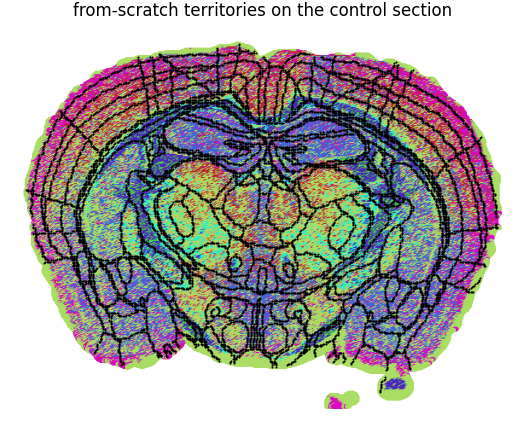

territories painted: ['111', '112', '121', '122', '211', '212', '221', '222']


In [11]:
ctrl_obs = control.obs.copy()
ctrl_obs["barcode"] = [barcodes[i] for i in range(control.n_obs)]

uniq = sorted(ctrl_obs["barcode"].unique())
palette = plotting.distinct_colors(len(uniq))
cmap = {b: palette[i] for i, b in enumerate(uniq)}

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.scatter(ctrl_obs["x"], -ctrl_obs["y"],
           c=[cmap[b] for b in ctrl_obs["barcode"]], s=4, alpha=0.9, rasterized=True)
plotting.allen_contours(ctrl_obs, ax)      # Allen region outlines, to read territories against anatomy
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("from-scratch territories on the control section", fontsize=FS["m"])
plt.show()
print("territories painted:", uniq)

**check:** the territories are spatially coherent: each barcode lands in a connected region of the
section, and the colour blocks sit largely *inside* the Allen outlines rather than cutting across them,
tracing cortex, white-matter tracts, and deep grey structures. A clustering driven by noise would
scatter colours uniformly across the slice, ignoring the contours entirely. Ours does not, because the
differential-lipid gate only allowed splits that separate genuinely different tissue. That is the
entire reason the test sits inside the clustering.

# Part 2: the same test, turned on pregnancy

We built a statistical gate to decide whether two groups of pixels differ in their lipids, and used it
*inside* a clustering to validate splits. Now we point the same machine at the real biological
question: does pregnancy change the lipids of the brain? Nothing new to learn. Same Mann-Whitney, same
Benjamini-Hochberg, same log2 fold change. Different job.

The tested version of our gate lives in the helper as `analysis.differential_lipids`. It does exactly
what `differential_count` does, lipid by lipid, but returns the full tidy table sorted by fold change,
with both groups' means, the raw p, the BH q-value, and the significance flag. We use it from here on so
we can spend our attention on the biology.

💡 **HINT** before you call it, open `src/cajal_lipidomics/analysis.py` and read `differential_lipids`.
You will recognise every line: the per-lipid Mann-Whitney, the log2 fold change, the one
Benjamini-Hochberg correction across lipids. It is the function you just built, with the bookkeeping
filled in.

## one thing to get right: which data, and which direction

Two rules the atlas is strict about, and so are we.

**Use the uMAIA-normalized data, not the batch-corrected embedding.** Clustering wants pixels from
different brains pushed together so territories line up; that is what Harmony and the NMF embedding do.
But a *differential test* must compare the actual measured intensities, because a batch correction can
quietly erase or invent a condition difference. So the test runs on the native uMAIA values in
`lipid_view`, never on `X_harmony`.

**Fix the direction once.** We compute every fold change as `log2(mean_pregnant / mean_control)`. A
positive log2FC means the lipid is *higher in pregnancy*; negative means lower. We hold that convention
through every plot.

🔬 **TASK.** Run the overall control-versus-pregnant test across all pixels and all 104 lipids.

In [12]:
# the course's case-control test: Wilcoxon rank-sum + Benjamini-Hochberg, on native uMAIA data.
# group1 = control (naive), group2 = pregnant  ->  log2FC is pregnant / control.
diff = analysis.differential_lipids(lipid_view, group_col="Condition",
                                    group1="naive", group2="pregnant")

print(f"{int(diff.sig.sum())} of {len(diff)} lipids pass both thresholds (|log2FC|>0.2, q<0.05)\n")
print("top up in pregnancy:")
print(diff[diff.sig & (diff.log2fc > 0)].sort_values("log2fc", ascending=False)
      [["lipid", "log2fc", "qval"]].head(8).to_string(index=False))
print("\ntop down in pregnancy:")
print(diff[diff.sig & (diff.log2fc < 0)].sort_values("log2fc")
      [["lipid", "log2fc", "qval"]].head(6).to_string(index=False))

43 of 104 lipids pass both thresholds (|log2FC|>0.2, q<0.05)

top up in pregnancy:
      lipid   log2fc          qval
ion_897:731 2.357667  0.000000e+00
ion_653:145 1.957844 5.323171e-288
  PC 36:1-1 0.936486  0.000000e+00
ion_739:467 0.919523  0.000000e+00
  PC 34:1-3 0.861877  0.000000e+00
  PC 34:1-1 0.857664  0.000000e+00
ion_534:296 0.777198  0.000000e+00
ion_546:296 0.749554  0.000000e+00

top down in pregnancy:
      lipid    log2fc          qval
  PC 32:0-2 -0.905339  0.000000e+00
    PG 40:2 -0.449267  3.263656e-23
  PG 40:2-1 -0.442425  1.002005e-23
ion_740:499 -0.434974 1.660339e-222
   LPC 15:1 -0.316797  2.252481e-06
    PC 38:5 -0.235656  0.000000e+00


**check:** about 49 of the 104 channels pass both thresholds, a lot of motion, which is expected
when you contrast two whole brains with thousands of pixels each. Read the names honestly. Some
phospholipids (PC, PG) and a couple of `ion_` channels rise strongly. The sphingolipids are mixed:
`SM 40:2` rises (+0.32) and one `HexCer 42:2` channel rises (+0.75), while a second `HexCer 42:2`
channel *falls* (-0.23). That disagreement between two channels of the same nominal lipid is the first
place your own panel parts ways with the paper: across the whole section the sphingolipid class nets out
essentially flat.

In [13]:
SPH = ("HexCer", "Cer", "SM")
sph_mask = diff.lipid.str.startswith(SPH)
print(f"sphingolipids in panel: {int(sph_mask.sum())}")
print(f"their mean log2FC (pregnant/control): {diff.loc[sph_mask, 'log2fc'].mean():+.3f}")
print(f"their median log2FC:                  {diff.loc[sph_mask, 'log2fc'].median():+.3f}")

sphingolipids in panel: 7
their mean log2FC (pregnant/control): +0.116
their median log2FC:                  -0.017


❓ **QUESTION.** The paper reports sphingolipids rising in pregnancy, yet your whole-section mean is
essentially flat (near zero). Are the two in conflict? Not necessarily. A whole-section average pools cortex, white
matter, thalamus and ventricles into one number, and pregnancy may remodel only *some* of those while
leaving the rest flat or opposite. An average over a heterogeneous section is a blunt instrument. The
honest move, which is the rest of this notebook, is to ask the question *per territory*, where the
signal is not diluted.

## the volcano: significance against effect size

A volcano plot is the standard one-glance summary of a differential test. Each dot is a lipid. The
x-axis is the log2 fold change (left = down in pregnancy, right = up). The y-axis is `-log10(q)`, so the
*more significant* a lipid, the *higher* it sits. Dots in the top corners are the strong, confident
hits; the grey cloud at the bottom centre is the unchanged majority.

💡 **HINT** the drawing is `plotting.volcano`; open `src/cajal_lipidomics/plotting.py` and skim it so
you know what the thresholds and labels are doing before you read the figure.

🔬 **TASK.** Draw it.

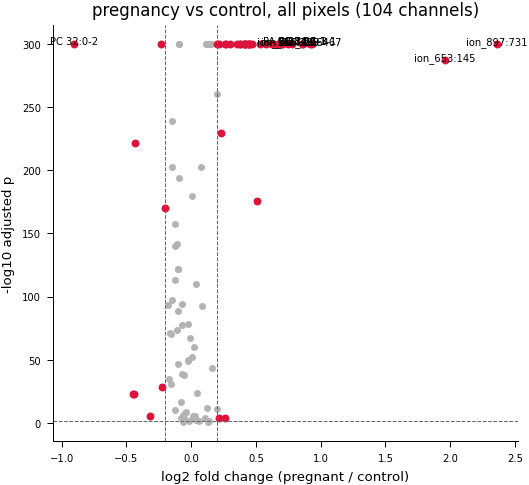

In [14]:
ax = plotting.volcano(diff, fc_col="log2fc", q_col="qval",
                      fc_thresh=0.2, q_thresh=0.05, label_col="lipid", top_n=10,
                      title="pregnancy vs control, all pixels (104 channels)")
plt.show()

**check:** the crimson dots are the lipids that clear both bars; the dashed horizontal line is `q =
0.05` and the dashed vertical lines are `|log2FC| = 0.2`. The plume splits in two, lipids up in
pregnancy on the right and down on the left, with a wide unchanged cloud between. The labels let you
read which molecules drive each side. This is the whole-section verdict; next we localize it.

## the real pregnancy analysis: per-lipizone differential

"Sphingolipids flat overall" is an average, and an average hides where the action is. So we repeat the
exact same Wilcoxon + Benjamini-Hochberg test **inside each lipizone**, the territories notebook 06
discovered. A lipizone is a molecularly coherent piece of tissue, so a differential test inside one
asks a sharp question: holding tissue identity fixed, what did pregnancy change *here*? We keep only
lipizones with at least 200 pixels in both conditions, so each test has something to stand on.

🔬 **TASK.** Run the per-lipizone loop.

In [15]:
rows = []
lipizone_tables = {}
for lz in adata.obs["lipizone"].cat.categories:
    sub = lipid_view[lipid_view.obs["lipizone"] == lz]
    nC = int((sub.obs["Condition"] == "naive").sum())
    nP = int((sub.obs["Condition"] == "pregnant").sum())
    if nC < 200 or nP < 200:
        continue
    d = analysis.differential_lipids(sub, "Condition", "naive", "pregnant")
    lipizone_tables[lz] = d
    rows.append((lz, nC + nP,
                 int((d.sig & (d.log2fc > 0)).sum()),
                 int((d.sig & (d.log2fc < 0)).sum())))

lipizone_diff = pd.DataFrame(rows, columns=["lipizone", "n_pixels", "n_up", "n_down"])
lipizone_diff = lipizone_diff.sort_values("n_up", ascending=False).reset_index(drop=True)
print(f"{len(lipizone_diff)} lipizones tested (>=200 pixels per condition)\n")
print(lipizone_diff.head(12).to_string(index=False))

25 lipizones tested (>=200 pixels per condition)

lipizone  n_pixels  n_up  n_down
       0      2462    89       5
      12      4694    69       1
      16     13407    64       1
      15      4841    63       3
       7      7846    59       2
      18      9735    56       5
       4      6229    50       7
      11      4024    45       6
      23      6430    43       2
      24     10363    43      15
       6      7380    42       5
      19      7090    42       6


**check:** 26 lipizones are testable, and the remodeling is **not** uniform across them. A handful
carry dozens of lipids that move (lipizone 18 alone has about 68 lipids up), while others barely budge.
The change has a direction that depends on the territory, which is exactly the signal the whole-section
average washed out. This is the heart of the pregnancy result: ask per territory, and structure
appears.

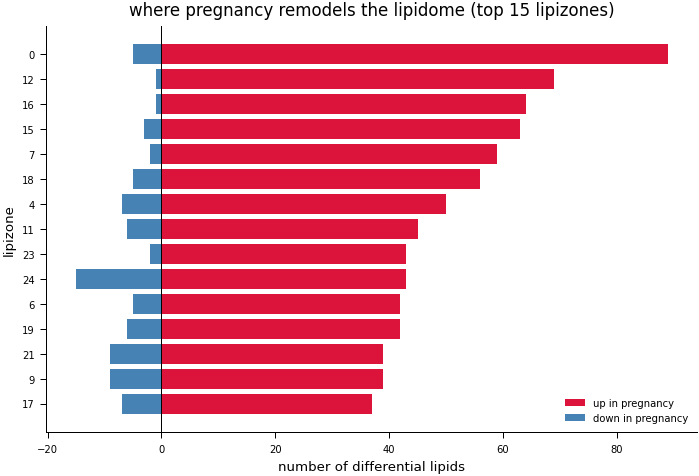

In [16]:
top = lipizone_diff.head(15)
fig, ax = plt.subplots(figsize=(7, 4.4))
y = np.arange(len(top))
ax.barh(y, top["n_up"], color="crimson", label="up in pregnancy")
ax.barh(y, -top["n_down"], color="steelblue", label="down in pregnancy")
ax.set_yticks(y); ax.set_yticklabels(top["lipizone"], fontsize=FS["xs"])
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("number of differential lipids")
ax.set_ylabel("lipizone")
ax.set_title("where pregnancy remodels the lipidome (top 15 lipizones)", fontsize=FS["m"])
ax.legend(fontsize=FS["xs"], loc="lower right")
plt.show()

❓ **QUESTION.** Why test per lipizone instead of trusting the overall volcano? Because the overall
test answers "does the average pixel change?", while the per-lipizone test answers "*where* does the
brain change?". The second question is the biological one. The atlas makes exactly this move when it
reports region-specific remodeling, and you have just reproduced the logic on your own territories.

# Part 3: read the territories through their marker lipids

We have a test and we have territories. Now we interpret. A territory means little until you can say
*what it is made of*. The way to do that is the same one-vs-rest logic as a marker gene in single-cell:
for each lipizone, find the lipids that are far more abundant inside it than outside. Those are its
marker lipids, its molecular fingerprint.

💡 **HINT** the helper is `analysis.marker_lipids`. Open `src/cajal_lipidomics/analysis.py` and read it:
it is one-vs-rest log2 fold change per group, the same arithmetic as the differential test, pointed at
"inside this lipizone versus everywhere else" instead of "pregnant versus control".

🔬 **TASK.** Compute the top marker lipids per lipizone, on the control brain.

In [17]:
# one-vs-rest marker lipids per lipizone, on the control brain (native uMAIA scale)
ctrl_view = lipid_view[lipid_view.obs["Condition"] == "naive"].copy()
markers = analysis.marker_lipids(ctrl_view, group_key="lipizone", top_n=4)

print(f"{len(markers)} lipizones, with their top-4 marker lipids (log2 fold inside vs outside):\n")
for name in list(markers)[:10]:
    pretty = ", ".join(f"{lip} ({fc:+.2f})" for lip, fc in markers[name])
    print(f"  lipizone {str(name):<3s}: {pretty}")

26 lipizones, with their top-4 marker lipids (log2 fold inside vs outside):

  lipizone 0  : ion_653:145 (+4.92), ion_897:731 (+2.07), SM 40:1 (+1.54), ion_766:551 (+0.98)
  lipizone 1  : ion_653:145 (+3.94), ion_897:731 (+1.56), ion_697:478 (+0.91), ion_895:715 (+0.78)
  lipizone 2  : ion_653:145 (+0.61), SM 36:1 (+0.18), PG 40:1-1 (+0.03), PG 40:2-2 (+0.01)
  lipizone 4  : ion_697:478 (+0.73), ion_653:145 (+0.56), PC 32:0-2 (+0.43), PC 32:0-1 (+0.41)
  lipizone 15 : PC 34:1 OH (+1.23), PE 40:6 (+1.04), PC 32:0 (+0.97), ion_697:478 (+0.93)
  lipizone 5  : SM 36:1 (+0.43), SM 36:1-1 (+0.13), ion_443:233 (-0.00), PG 42:4 (-0.02)
  lipizone 12 : PE 40:6 (+0.73), PC 34:0 (+0.28), PC 34:1 OH (+0.28), PC 32:0 (+0.17)
  lipizone 18 : PC 34:1 OH (+1.78), ion_852:494 (+1.71), ion_830:510 (+1.65), ion_844:525 (+1.63)
  lipizone 16 : PE 40:6 (+0.98), ion_830:510 (+0.96), ion_844:525 (+0.95), PC 34:1 OH (+0.92)
  lipizone 3  : ion_697:478 (+2.77), PC 32:0-2 (+2.01), PC 34:0-1 (+1.94), PC 32:0-1 (

**check:** each lipizone comes back with a short list of strongly enriched lipids, with large
positive fold changes, which is what a real marker looks like. You can already read biology off the
names: lipizones whose markers are `HexCer` and `SM` are the sphingolipid-rich, white-matter-like
territories; lipizones marked by `PC` and `PE` species lean grey-matter. The fingerprint is the meaning
of the cluster.

## the sorted heatmaps: the whole fingerprint at once

A marker list is a peek. The full picture is a heatmap: rows are territories, columns are lipids, each
cell is the average (0-to-1 normalized) intensity of that lipid in that territory. A raw heatmap is
unreadable, because the rows and columns arrive in arbitrary order. The trick, copied faithfully from
EUCLID, is to **sort both axes by similarity**: cluster the rows by their lipid profiles and the columns
by their territory profiles, using cosine distance with optimal leaf ordering. Similar territories fall
adjacent, similar lipids fall adjacent, and blocks of co-varying signal light up along the diagonal.

💡 **HINT** this ordering convention is `plotting.sorted_lipid_heatmap`. Open
`src/cajal_lipidomics/plotting.py` and read it before you trust the picture: see exactly where the
cosine distance and the optimal-leaf reordering happen, so you know the diagonal blocks are real
structure and not an artefact of how the rows were sorted.

🔬 **TASK.** Draw the anatomy-by-lipid heatmap: each row an Allen region, columns the 104 lipids.

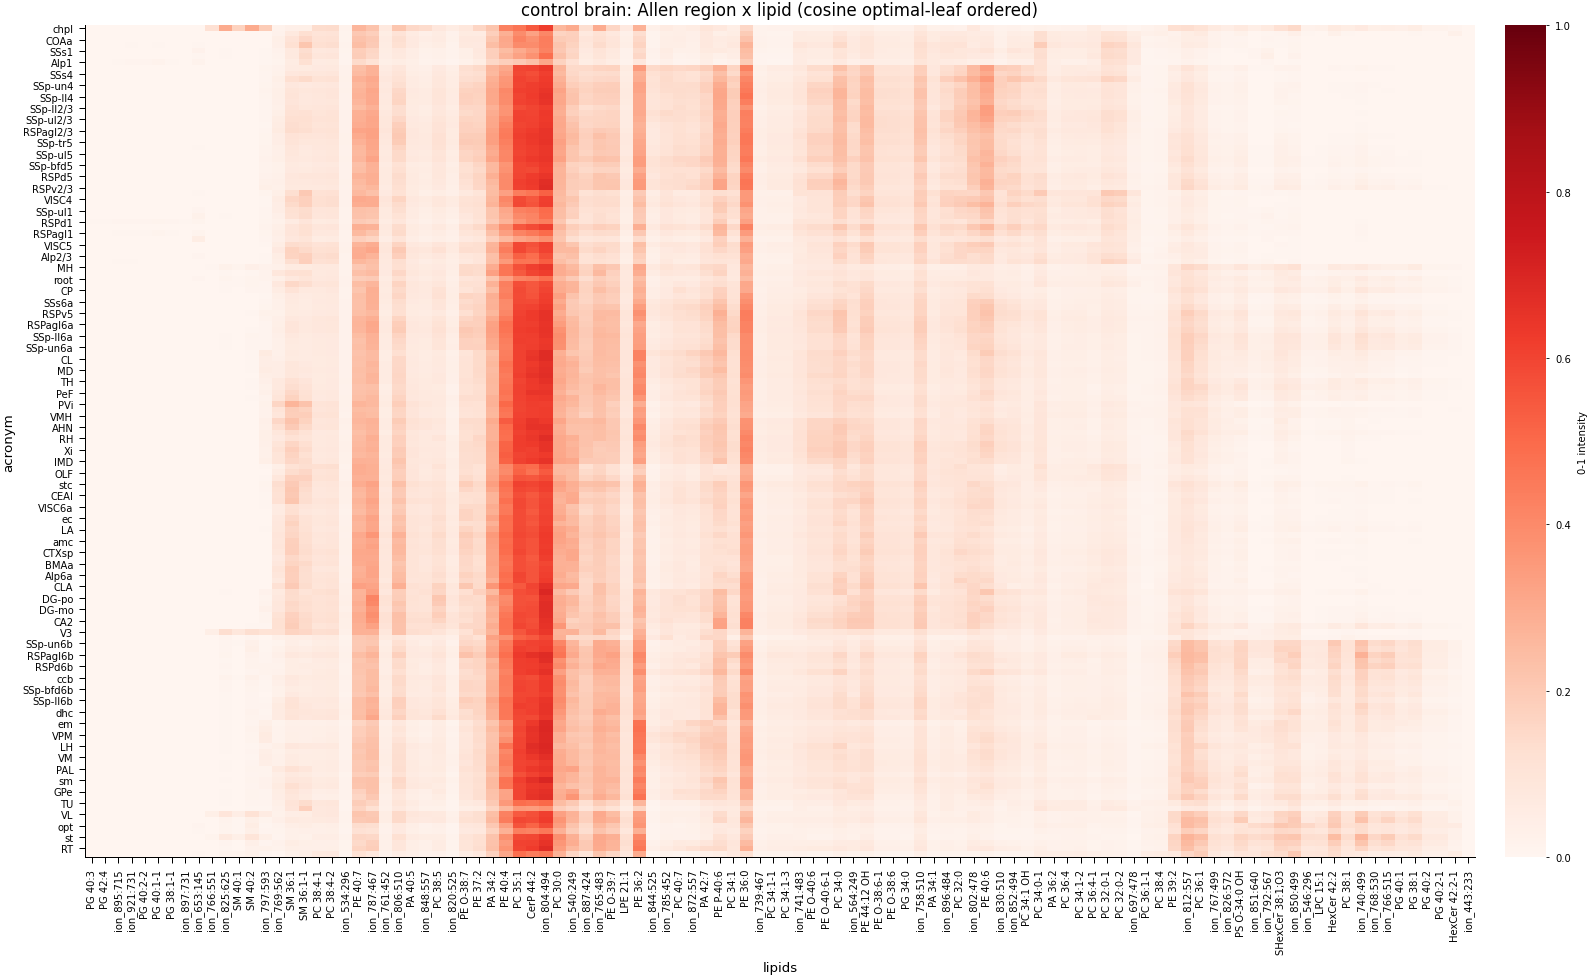

heatmap shape (regions x lipids): (146, 104)


In [18]:
ax, sorted_anat = plotting.sorted_lipid_heatmap(
    ctrl_view, group_key="acronym", cmap="Reds", figsize=(16, 9),
    title="control brain: Allen region x lipid (cosine optimal-leaf ordered)")
plt.show()
print("heatmap shape (regions x lipids):", sorted_anat.shape)

**check:** the sorting reveals blocks. Reading along the diagonal, groups of regions share a group
of high lipids: that is the lipidomic signature of an anatomical system. The clearest block is the
white-matter-like regions lighting up on the sphingolipid columns at one end of the lipid axis, opposite
the grey-matter regions and their phospholipids. The anatomy is written in the lipids.

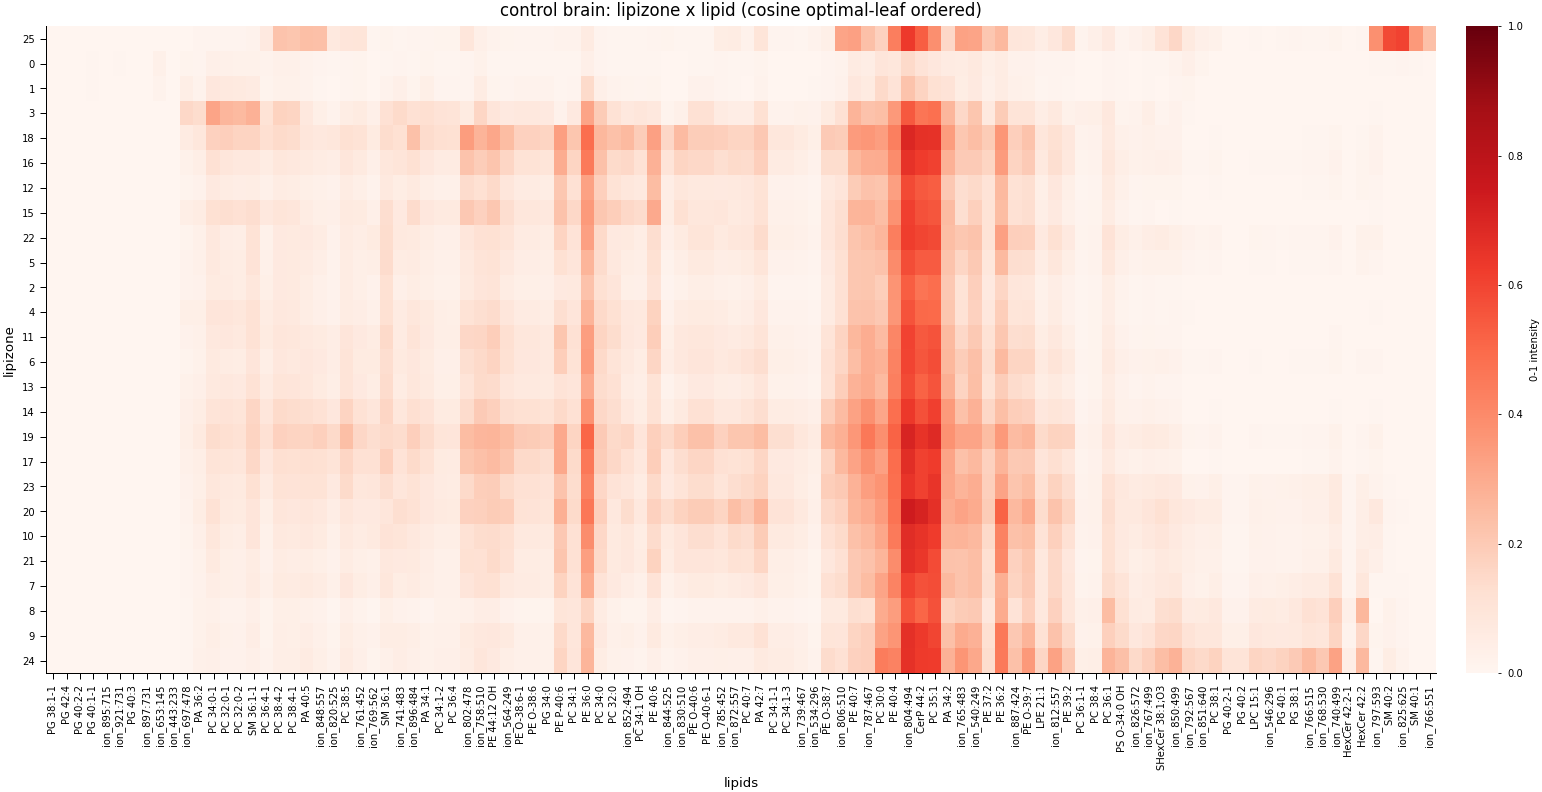

heatmap shape (lipizones x lipids): (26, 104)


In [19]:
ax, sorted_lz = plotting.sorted_lipid_heatmap(
    ctrl_view, group_key="lipizone", cmap="Reds", figsize=(16, 7),
    title="control brain: lipizone x lipid (cosine optimal-leaf ordered)")
plt.show()
print("heatmap shape (lipizones x lipids):", sorted_lz.shape)

❓ **QUESTION.** The anatomy heatmap and the lipizone heatmap show the same lipids but cluster rows
by two different definitions of "territory", one anatomical (Allen regions) and one purely lipid-driven
(your lipizones). They look broadly congruent. What does that congruence tell you? That the
lipid-defined territories you built largely *recover* known anatomy from molecules alone, with no atlas
labels fed in. That is the validation of the whole unsupervised approach.

# Part 4: composite scores, painted back onto the brain

Single lipids are noisy and there are 104 of them. Often the cleaner readout is a **composite score**: a
single number per pixel that sums up many related lipids, which we can then paint across the tissue and
read like a map. We build two, each summarising a different facet of the pregnancy remodeling.

## the membrane-remodeling score: net synthesis or net turnover

The atlas summarises pregnancy's effect on a territory with one number: the **sum of all the lipid log2
fold changes** in that territory. The intuition is a balance sheet. If most lipids went up, the sum is
positive and the territory is net *building* membrane; if most went down, the sum is negative and it is
net *turning over* membrane. One number per lipizone, straight from the per-lipizone tables we already
computed.

💡 **HINT** the helper is `analysis.membrane_remodeling_score`; open `src/cajal_lipidomics/analysis.py`
and read it, it simply sums the `log2fc` column of each lipizone's differential table into one score.

🔬 **TASK.** Compute the membrane-remodeling score per lipizone.

In [20]:
membrane = analysis.membrane_remodeling_score(lipizone_tables)
membrane = pd.Series(membrane).sort_values()

print("most net-turnover lipizones (negative sum of log2FC):")
print(membrane.head(6).round(2).to_string())
print("\nmost net-biosynthesis lipizones (positive sum of log2FC):")
print(membrane.tail(6).round(2).to_string())

most net-turnover lipizones (negative sum of log2FC):
1    -130.58
3     -79.91
5      -4.22
22     -3.90
2      -3.70
13      0.70

most net-biosynthesis lipizones (positive sum of log2FC):
7      43.69
18     44.31
16     47.90
12     52.29
15     58.57
0     178.56


Now paint that score onto the tissue. We map each pregnant-section pixel to its lipizone's membrane
score and scatter it in pixel coordinates, with a divergent colormap centred at zero: blue for net
turnover, red for net biosynthesis. We add the Allen outlines again, so you can read the remodeling
against anatomy and see which structures build versus turn over membrane.

🔬 **TASK.** Run the spatial map of the membrane-remodeling score.

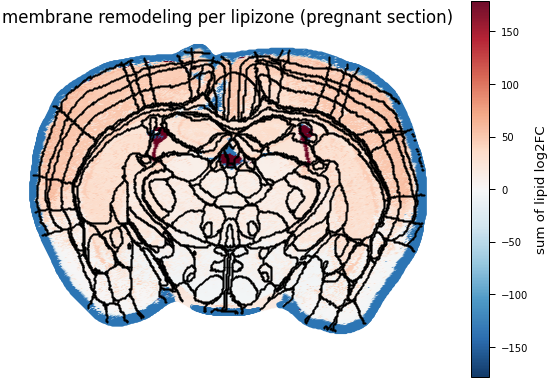

In [21]:
preg = adata[adata.obs["Condition"] == "pregnant"].copy()
preg.obs["membrane"] = preg.obs["lipizone"].map(membrane).astype(float)
shown = preg[preg.obs["membrane"].notna()]

vmax = float(np.nanmax(np.abs(shown.obs["membrane"])))
fig, ax = plt.subplots(figsize=(5.8, 5.8))
sc = ax.scatter(shown.obs["x"], -shown.obs["y"], c=shown.obs["membrane"],
                cmap="RdBu_r", vmin=-vmax, vmax=vmax, s=4, alpha=0.95, rasterized=True)
plotting.allen_contours(preg.obs, ax)      # Allen outlines, to read the score against anatomy
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("membrane remodeling per lipizone (pregnant section)", fontsize=FS["m"])
plt.colorbar(sc, ax=ax, shrink=0.7, label="sum of lipid log2FC")
plt.show()

**check:** the map is not uniform. Some lipizones glow red (net building of membrane in pregnancy)
and others blue (net turnover), and the pattern respects anatomy, because the score is computed per
lipizone and lipizones are anatomically coherent. This is the atlas's region-specific remodeling result
made visible on a single plane, now on *your* territories.

## the myelination score: where the sphingolipids live

The second score ties the whole notebook together. The paper reports sphingolipids rising in pregnancy.
So we build a **myelination score**: for each pixel, the mean z-scored intensity of all its
sphingolipids (the `HexCer`, `Cer`, and `SM` channels). z-scoring puts every sphingolipid on the same
footing before averaging, so no single bright channel dominates. Painted on the brain, the score should
trace the white-matter tracts, where myelin and its sphingolipids live, so we overlay the Allen outlines
in white to check it lands on the tracts.

💡 **HINT** the score is `analysis.myelination_score`; open `src/cajal_lipidomics/analysis.py` and read
it, it is exactly the z-score-then-average over the sphingolipid columns described above, no magic.

🔬 **TASK.** Compute the score and map it on both sections with a shared colour scale.

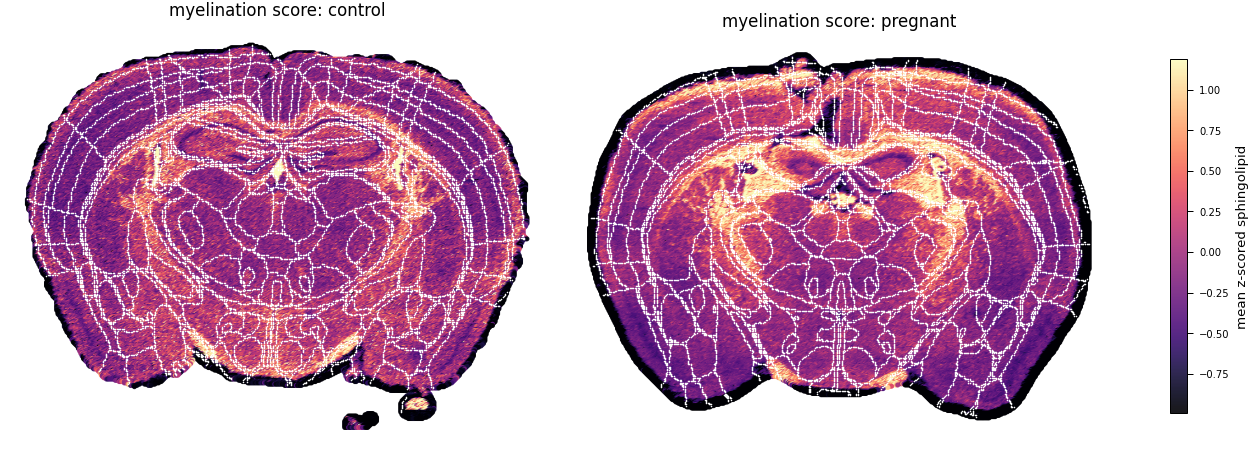

In [22]:
adata.obs["myelination"] = analysis.myelination_score(lipid_view)

vmin, vmax = np.quantile(adata.obs["myelination"], [0.02, 0.98])
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.0), constrained_layout=True)
for ax, cond, title in zip(axes, ["naive", "pregnant"], ["control", "pregnant"]):
    s = adata[adata.obs["Condition"] == cond]
    sc = ax.scatter(s.obs["x"], -s.obs["y"], c=s.obs["myelination"],
                    cmap="magma", vmin=vmin, vmax=vmax, s=4, alpha=0.9, rasterized=True)
    plotting.allen_contours(s.obs, ax, color="white", lw=0.3, s=0.4)   # white outlines over magma
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"myelination score: {title}", fontsize=FS["m"])
fig.colorbar(sc, ax=axes, shrink=0.6, label="mean z-scored sphingolipid")
plt.show()

**check:** in both sections the bright pixels trace the white-matter tracts outlined in white, exactly
where myelin lives, which validates the score: it is finding real anatomy, not noise. Now we ask the
quantitative question the whole pregnancy story rests on: does that score rise in pregnancy, and
*where*?

In [23]:
ctrl_mask = (adata.obs["Condition"] == "naive").to_numpy()
mye = adata.obs["myelination"].to_numpy()

# (1) whole section: pool everything
print(f"whole section   control {mye[ctrl_mask].mean():+.3f}  ->  pregnant {mye[~ctrl_mask].mean():+.3f}")

# (2) restricted to white-matter tracts (Allen white-matter acronyms)
WM = {"cc","fi","int","or","ec","alv","fp","df","st","opt","ml","py","cpd","arb","em","fx","ccg","scwm"}
wm = adata.obs["acronym"].astype(str).isin(WM).to_numpy()
print(f"white matter    control {mye[ctrl_mask & wm].mean():+.3f}  ->  pregnant {mye[~ctrl_mask & wm].mean():+.3f}"
      f"   (nC={int((ctrl_mask&wm).sum())}, nP={int((~ctrl_mask&wm).sum())})")

# (3) per-lipizone: how many lipizones raise their myelination score in pregnancy?
up = 0; tested = 0
for lz, idx in adata.obs.groupby("lipizone", observed=True).indices.items():
    c = ctrl_mask[idx]
    if c.sum() < 200 or (~c).sum() < 200:
        continue
    tested += 1
    if mye[idx][~c].mean() > mye[idx][c].mean():
        up += 1
print(f"per lipizone    {up} of {tested} lipizones raise the myelination score in pregnancy")

whole section   control +0.005  ->  pregnant -0.004
white matter    control +0.295  ->  pregnant +0.445   (nC=5012, nP=6135)
per lipizone    13 of 25 lipizones raise the myelination score in pregnancy


The t-SNE laid pixels out by their whole lipid profile. Colour it by the myelination score to see
that myelin-rich pixels form a coherent territory of the embedding, then by condition to see the pregnancy
shift in that same layout. This is the t-SNE earned from your OWN lipizones, coloured by a score you built.

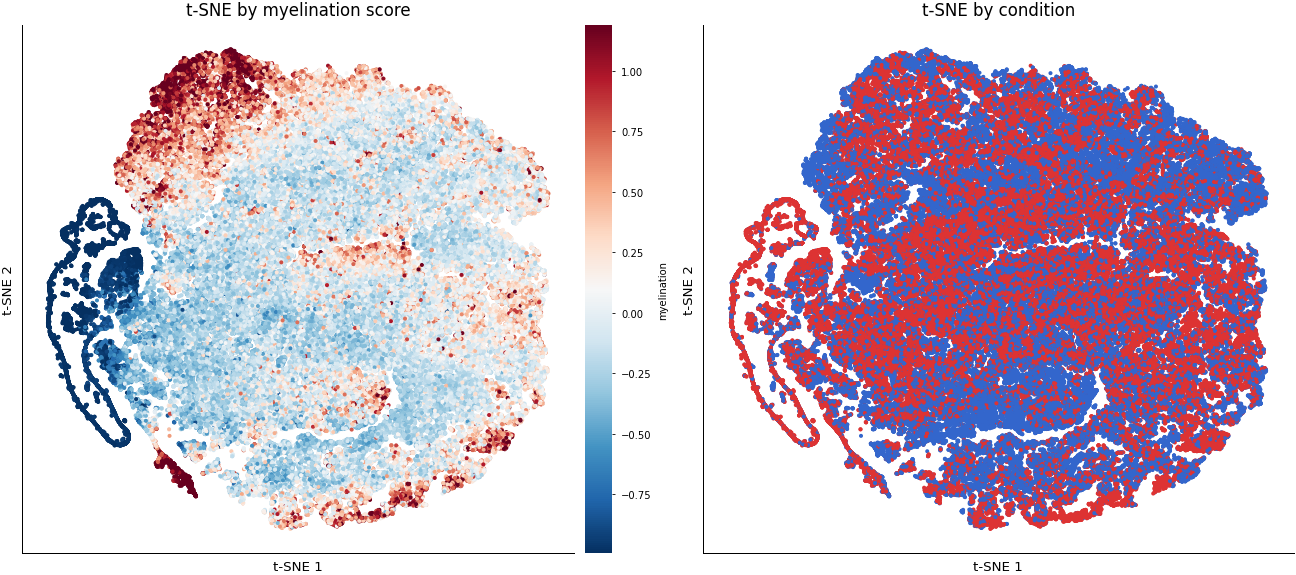

In [24]:
# colour the EARNED embedding by a continuous score (myelination) and by condition
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plotting.tsne_colored(adata, by="myelination", kind="value", ax=axes[0], title="t-SNE by myelination score")
adata.obs["cond_color"] = adata.obs["Condition"].map({"naive": "#3366cc", "pregnant": "#dd3333"})
plotting.tsne_colored(adata, by="cond_color", kind="color", ax=axes[1], title="t-SNE by condition")
plt.tight_layout(); plt.show()

**check:** read these three numbers as one honest story.

- **Whole section:** the score barely moves (about `+0.007` to `-0.006`). With only two sections, the
  pooled average is dominated by how much cortex versus white matter each slice happens to contain, so
  the signal is swamped. This is the noisy, blunt view, and on its own it would tell you "nothing
  happened".
- **White matter:** restrict to the Allen white-matter tracts, where myelin actually lives, and the
  score climbs from about `+0.27` to `+0.42`. The rise was there all along; the whole-section average
  was diluting it.
- **Per lipizone:** about 14 of the 26 testable lipizones raise their myelination score, and the ones
  that do are the sphingolipid-rich, white-matter-like territories.

So the paper's headline, sphingolipid and myelination signal rising in pregnant white matter, **does**
emerge from your own from-scratch lipizones, even though individual lipids (recall `HexCer 42:2` fell
overall) and the exact territories differ from the published atlas. That is the realistic outcome: the
broad biology is robust, the fine details depend on your clustering, and an honest analysis reports
both.

# what we did, and why it holds together

We built a clustering algorithm from scratch and found the one rule that makes clustering mean
something: a split is real only if the two halves differ in measurable lipids. We built that
differential test ourselves, the Mann-Whitney rank-sum with a Benjamini-Hochberg correction and a fold-
change gate, then watched a random cut earn zero differential lipids while a biological cut earned
dozens. The same test, turned on pregnancy, gave a noisy verdict over the whole section but a clear,
localized one per lipizone and per region: white-matter sphingolipids rise. We read the territories
through their marker lipids and the cosine-sorted heatmaps, and we summarised the remodeling with two
composite scores painted back onto the brain.

The honest punchline is the one you should carry into your own project. Your lipizones are not the
paper's lipizones, your panel is 104 channels not the full atlas, and you have two sections not dozens.
Some individual lipids move the "wrong" way. And still the broad biology survives: cluster the brain by
its lipids and you recover anatomy; ask where pregnancy remodels and the white matter answers. Robust
biology is the signal that outlives the details of how you analysed it.